
### Распределения, гипотезы, тесты, доверительные интервалы

## Импорты

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

---
## Описательная статистика

In [ ]:
df_hw = pd.read_csv('datasets/HeightWeight.csv')
print(f"Размер: {df_hw.shape}")
df_hw.head()

Размер: (25000, 3)


,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


### Mean, Median, Mode

In [ ]:
height = df_hw['Height(Inches)']

print(f"Mean (среднее):   {height.mean():.4f}")
print(f"Median (медиана): {height.median():.4f}")
print(f"Mode (мода):      {height.mode()[0]:.4f}")
print()
print(f"Std (станд. откл.): {height.std():.4f}")
print(f"Variance (дисперс.): {height.var():.4f}")
print(f"IQR:                 {height.quantile(0.75) - height.quantile(0.25):.4f}")

Mean (среднее):   67.9931
Median (медиана): 67.9957
Mode (мода):      65.6580

Std (станд. откл.): 1.9017
Variance (дисперс.): 3.6164
IQR:                 2.5686


### Skewness - асимметрия распределения

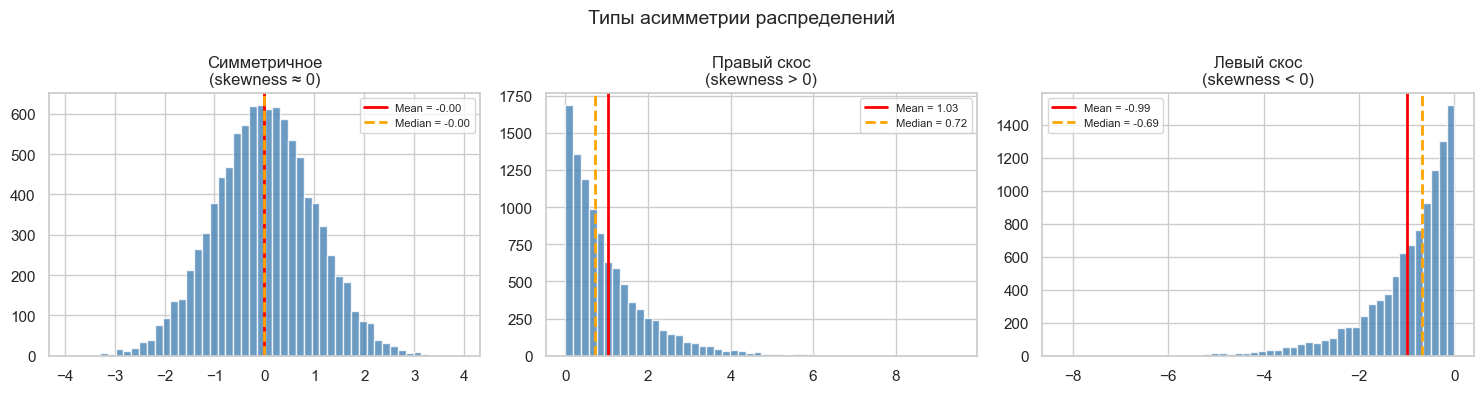

Skewness роста: -0.0057


In [ ]:
np.random.seed(42)
symmetric = np.random.normal(loc=0, scale=1, size=10000)
right_skewed = np.random.exponential(scale=1, size=10000)  
left_skewed = -np.random.exponential(scale=1, size=10000)  

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, title in zip(axes,
                            [symmetric, right_skewed, left_skewed],
                            ['Симметричное\n(skewness ≈ 0)', 'Правый скос\n(skewness > 0)', 'Левый скос\n(skewness < 0)']):
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(data), color='red', linewidth=2, label=f'Mean = {np.mean(data):.2f}')
    ax.axvline(np.median(data), color='orange', linewidth=2, linestyle='--', label=f'Median = {np.median(data):.2f}')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Типы асимметрии распределений', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Skewness роста: {height.skew():.4f}")

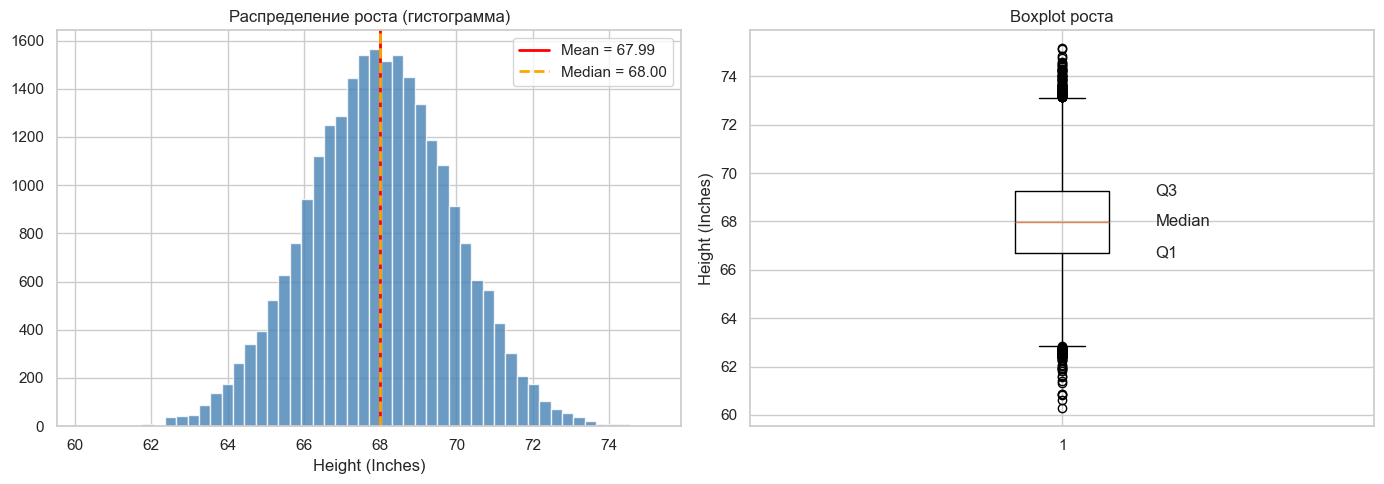

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(height, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(height.mean(), color='red', linewidth=2, label=f'Mean = {height.mean():.2f}')
axes[0].axvline(height.median(), color='orange', linewidth=2, linestyle='--', label=f'Median = {height.median():.2f}')
axes[0].set_title('Распределение роста (гистограмма)')
axes[0].set_xlabel('Height (Inches)')
axes[0].legend()

axes[1].boxplot(height, vert=True)
axes[1].set_title('Boxplot роста')
axes[1].set_ylabel('Height (Inches)')
axes[1].text(1.15, height.quantile(0.25), 'Q1', va='center')
axes[1].text(1.15, height.median(), 'Median', va='center')
axes[1].text(1.15, height.quantile(0.75), 'Q3', va='center')

plt.tight_layout()
plt.show()

---
##  Распределения

### Нормальное распределение и правило 68-95-99.7

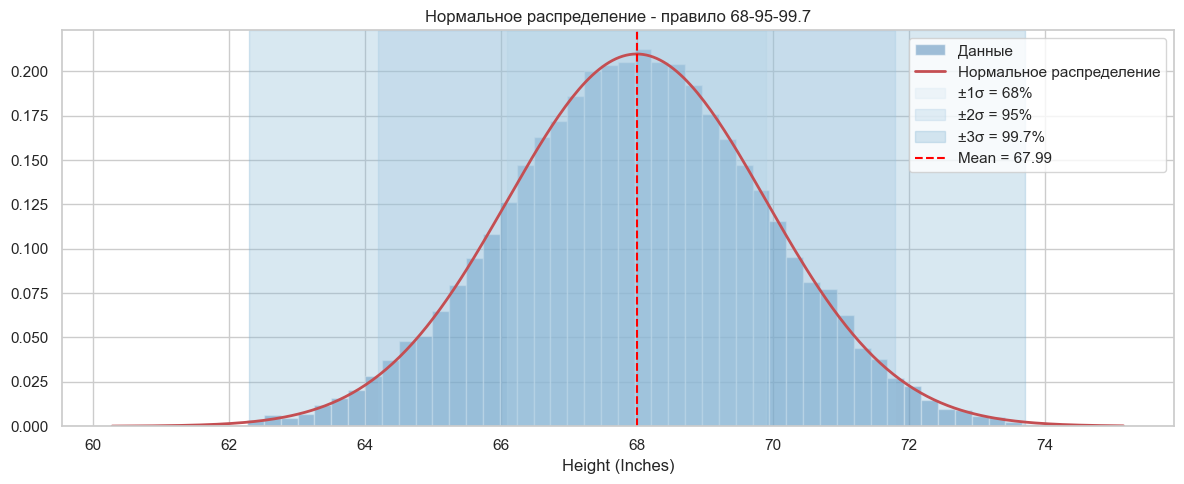

Mean: 67.99, Std: 1.90
±1σ: [66.09, 69.89] → 68.4% значений
±2σ: [64.19, 71.80] → 95.5% значений
±3σ: [62.29, 73.70] → 99.8% значений


In [ ]:
mu = height.mean()
sigma = height.std()

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(height, bins=60, density=True, color='steelblue', alpha=0.5, label='Данные')

x = np.linspace(height.min(), height.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Нормальное распределение')

colors = ['#d4e6f1', '#a9cce3', '#7fb3d3']
for i, (k, c, label) in enumerate(zip([1, 2, 3], colors, ['68%', '95%', '99.7%'])):
    ax.axvspan(mu - k*sigma, mu + k*sigma, alpha=0.3, color=c, label=f'±{k}σ = {label}')

ax.axvline(mu, color='red', linewidth=1.5, linestyle='--', label=f'Mean = {mu:.2f}')
ax.set_title('Нормальное распределение - правило 68-95-99.7')
ax.set_xlabel('Height (Inches)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean: {mu:.2f}, Std: {sigma:.2f}")
print(f"±1σ: [{mu-sigma:.2f}, {mu+sigma:.2f}] -> {((height.between(mu-sigma, mu+sigma)).sum()/len(height)*100):.1f}% значений")
print(f"±2σ: [{mu-2*sigma:.2f}, {mu+2*sigma:.2f}] -> {((height.between(mu-2*sigma, mu+2*sigma)).sum()/len(height)*100):.1f}% значений")
print(f"±3σ: [{mu-3*sigma:.2f}, {mu+3*sigma:.2f}] -> {((height.between(mu-3*sigma, mu+3*sigma)).sum()/len(height)*100):.1f}% значений")

### Проверка нормальности: Shapiro-Wilk + Q-Q plot

In [ ]:
# Используем подвыборку, т.к. Shapiro-Wilk работает до n=5000
sample = height.sample(n=1000, random_state=42)
stat, p_value = stats.shapiro(sample)
print(f"Shapiro-Wilk тест:")
print(f"  Статистика: {stat:.4f}")
print(f"  p-value:    {p_value:.4f}")
print(f"  Вывод: {'Нормальное распределение (p > 0.05)' if p_value > 0.05 else 'Не нормальное (p ≤ 0.05)'}")

Shapiro-Wilk тест:
  Статистика: 0.9987
  p-value:    0.6683
  Вывод: Нормальное распределение (p > 0.05)


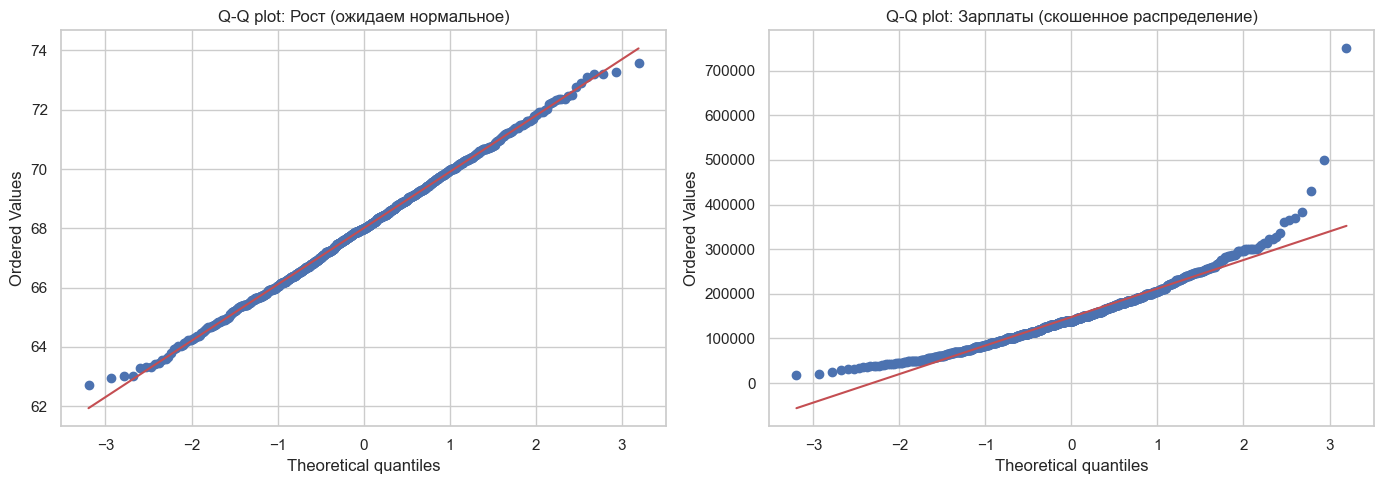

Если точки лежат на прямой → распределение нормальное
Отклонения в хвостах → ненормальное


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q plot для нормального роста
stats.probplot(sample, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q plot: Рост (ожидаем нормальное)')

# Q-Q plot для скошенных данных (зарплаты) - для сравнения
df_salary = pd.read_csv('datasets/salary.csv')
salary_sample = df_salary['salary_in_usd'].sample(n=1000, random_state=42)
stats.probplot(salary_sample, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot: Зарплаты (скошенное распределение)')

plt.tight_layout()
plt.show()
print("Если точки лежат на прямой -> распределение нормальное")
print("Отклонения в хвостах -> ненормальное")

### Центральная предельная теорема (ЦПТ)

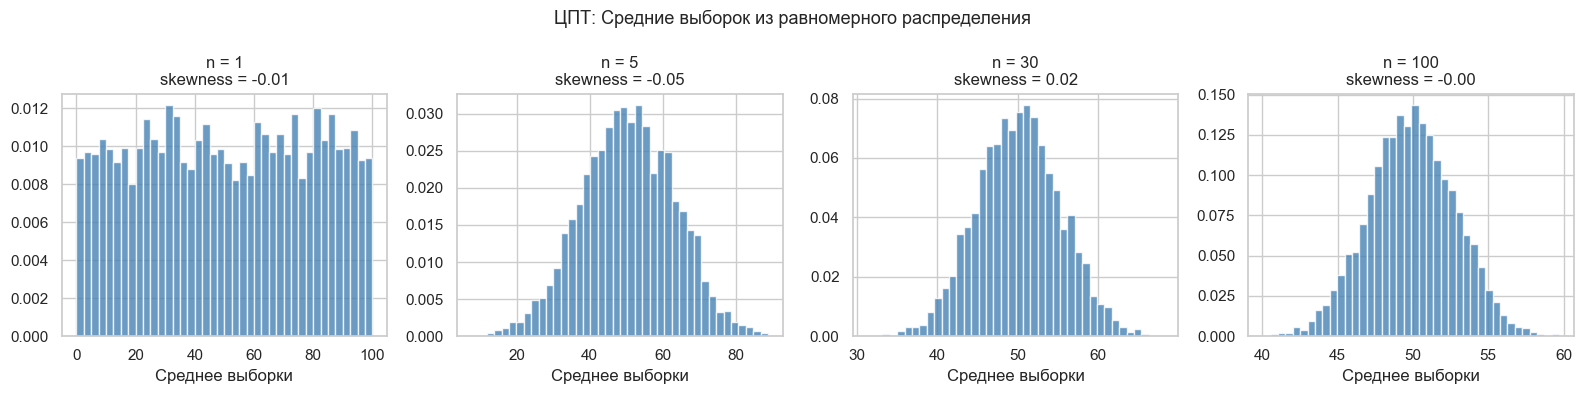

При n ≥ 30 средние выборок становятся нормально распределены
Это позволяет применять нормальные тесты к ненормальным данным при большой выборке


In [ ]:
# Берём равномерное распределение - явно не нормальное
np.random.seed(42)
population = np.random.uniform(0, 100, size=100_000)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sample_sizes = [1, 5, 30, 100]
for ax, n in zip(axes, sample_sizes):
    sample_means = [np.mean(np.random.choice(population, size=n)) for _ in range(5000)]
    ax.hist(sample_means, bins=40, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    ax.set_title(f'n = {n}\nskewness = {pd.Series(sample_means).skew():.2f}')
    ax.set_xlabel('Среднее выборки')

plt.suptitle('ЦПТ: Средние выборок из равномерного распределения', fontsize=13)
plt.tight_layout()
plt.show()
print("При n ≥ 30 средние выборок становятся нормально распределены")
print("Это позволяет применять нормальные тесты к ненормальным данным при большой выборке")

---
##  Доверительные интервалы

In [ ]:
# CI для среднего роста
n = len(height)
mean = height.mean()
se = stats.sem(height)   # standard error = std / sqrt(n)

ci_95 = stats.t.interval(confidence=0.95, df=n-1, loc=mean, scale=se)
ci_99 = stats.t.interval(confidence=0.99, df=n-1, loc=mean, scale=se)

print(f"Среднее: {mean:.4f}")
print(f"95% CI:  [{ci_95[0]:.4f}, {ci_95[1]:.4f}]  (ширина: {ci_95[1]-ci_95[0]:.4f})")
print(f"99% CI:  [{ci_99[0]:.4f}, {ci_99[1]:.4f}]  (ширина: {ci_99[1]-ci_99[0]:.4f})")

Среднее: 67.9931
95% CI:  [67.9695, 68.0167]  (ширина: 0.0471)
99% CI:  [67.9621, 68.0241]  (ширина: 0.0620)

Вывод: 99% CI шире - чтобы быть увереннее, нам нужен больший диапазон


### Как размер выборки влияет на CI

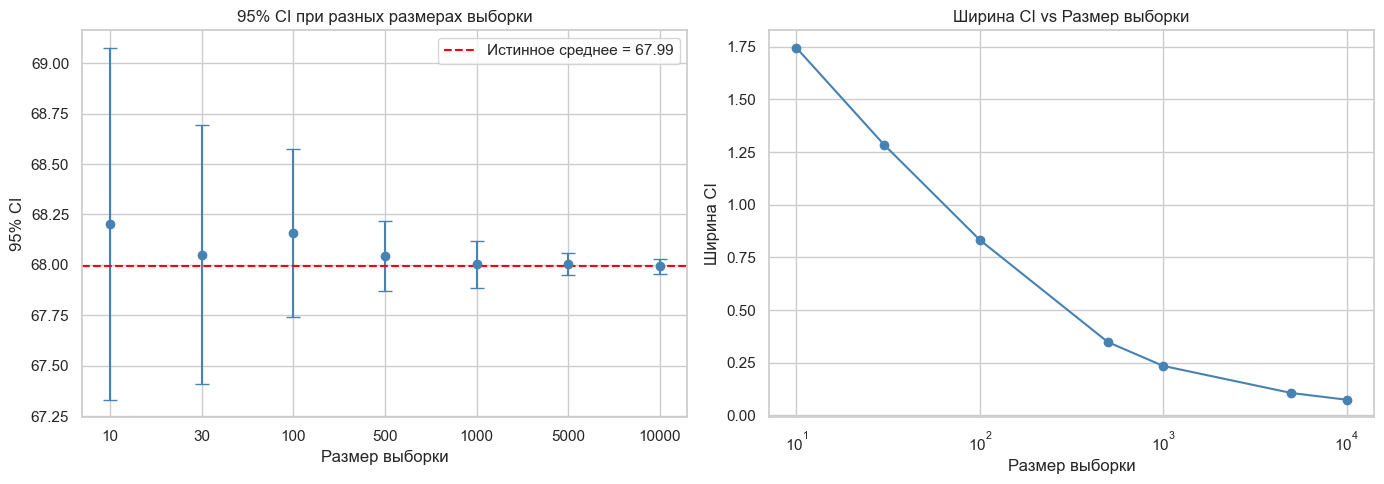

Размер выборки -> ширина 95% CI:
  n =     10: ±0.8721
  n =     30: ±0.6426
  n =    100: ±0.4164
  n =    500: ±0.1739
  n =   1000: ±0.1175
  n =   5000: ±0.0532
  n =  10000: ±0.0373


In [ ]:
sample_sizes = [10, 30, 100, 500, 1000, 5000, 10000]
widths = []
ci_lowers = []
ci_uppers = []

np.random.seed(42)
for n_s in sample_sizes:
    sample = height.sample(n=n_s, random_state=42)
    ci = stats.t.interval(0.95, df=n_s-1, loc=sample.mean(), scale=stats.sem(sample))
    ci_lowers.append(ci[0])
    ci_uppers.append(ci[1])
    widths.append(ci[1] - ci[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(range(len(sample_sizes)), 
                 [(l+u)/2 for l, u in zip(ci_lowers, ci_uppers)],
                 yerr=[(u-l)/2 for l, u in zip(ci_lowers, ci_uppers)],
                 fmt='o', capsize=5, color='steelblue')
axes[0].axhline(height.mean(), color='red', linestyle='--', label=f'Истинное среднее = {height.mean():.2f}')
axes[0].set_xticks(range(len(sample_sizes)))
axes[0].set_xticklabels(sample_sizes)
axes[0].set_xlabel('Размер выборки')
axes[0].set_ylabel('95% CI')
axes[0].set_title('95% CI при разных размерах выборки')
axes[0].legend()

axes[1].plot(sample_sizes, widths, 'o-', color='steelblue')
axes[1].set_xlabel('Размер выборки')
axes[1].set_ylabel('Ширина CI')
axes[1].set_title('Ширина CI и Размер выборки')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

print("Размер выборки -> ширина 95% CI:")
for n_s, w in zip(sample_sizes, widths):
    print(f"  n = {n_s:>6}: ±{w/2:.4f}")

---
##  Проверка гипотез - концепция

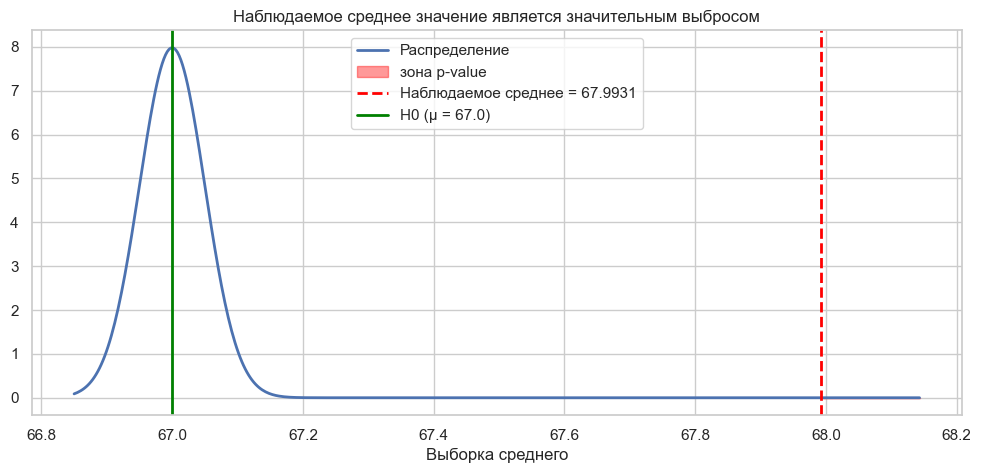

In [ ]:
h0_mean = 67.0
observed_mean = 67.9931
se_height = 0.05 

x_min = min(h0_mean, observed_mean) - 3*se_height
x_max = max(h0_mean, observed_mean) + 3*se_height
x = np.linspace(x_min, x_max, 500)
y = stats.norm.pdf(x, h0_mean, se_height)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(x, y, 'b-', linewidth=2, label='Распределение')

ax.fill_between(x, y, where=(x >= observed_mean), alpha=0.4, color='red', label='зона p-value')
mirror_point = h0_mean - (observed_mean - h0_mean)
ax.fill_between(x, y, where=(x <= mirror_point), alpha=0.4, color='red')

ax.axvline(observed_mean, color='red', linewidth=2, linestyle='--', label=f'Наблюдаемое среднее = {observed_mean:.4f}')
ax.axvline(h0_mean, color='green', linewidth=2, label=f'H0 (μ = {h0_mean})')

ax.set_title('Наблюдаемое среднее значение является значительным выбросом')
ax.set_xlabel('Выборка среднего')
ax.legend()
plt.show()

---
## Статистические тесты

### t-тест: одновыборочный

In [ ]:
# H0: среднее = 67.0 дюймов
# H1: среднее ≠ 67.0 дюймов
h0_value = 67.0

# Проверяем условия
print(f"1. Размер выборки: n = {len(height)}  (n ≥ 30)")
shapiro_stat, shapiro_p = stats.shapiro(height.sample(1000, random_state=42))
print(f"2. Shapiro-Wilk (подвыборка 1000): p = {shapiro_p:.4f}  (при n=25000 ЦПТ работает в любом случае)")
print(f"3. Независимость: каждый человек - отдельное наблюдение")
print()

# Тест
t_stat, p_value = stats.ttest_1samp(height, popmean=h0_value)
n = len(height)
ci = stats.t.interval(0.95, df=n-1, loc=height.mean(), scale=stats.sem(height))

print(f"H₀: μ = {h0_value}")
print(f"Наблюдаемое среднее: {height.mean():.4f}")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.2e}")
print(f"95% CI: [{ci[0]:.4f}, {ci[1]:.4f}]")
print()
alpha = 0.05
if p_value < alpha:
    print(f" p = {p_value:.2e} < α = {alpha}")
    print(f"Вывод: Отвергаем H₀. Среднее значимо отличается от {h0_value}.")
    print(f"С 95% уверенностью: истинное среднее в диапазоне [{ci[0]:.2f}, {ci[1]:.2f}]")
else:
    print(f"H₀ не отвергается (p = {p_value:.4f} ≥ α = {alpha})")

1. Размер выборки: n = 25000  (n ≥ 30)
2. Shapiro-Wilk (подвыборка 1000): p = 0.6683  (при n=25000 ЦПТ работает в любом случае)
3. Независимость: каждый человек - отдельное наблюдение

H₀: μ = 67.0
Наблюдаемое среднее: 67.9931
t-статистика: 82.5718
p-value: 0.00e+00
95% CI: [67.9695, 68.0167]

 p = 0.00e+00 < α = 0.05
Вывод: Отвергаем H₀. Среднее значимо отличается от 67.0.
С 95% уверенностью: истинное среднее в диапазоне [67.97, 68.02]


### Chi-squared тест: Titanic - пол и выживаемость

In [ ]:
df_titanic = pd.read_csv('datasets/Titanic_Dataset.csv')

ct = pd.crosstab(df_titanic['Sex'], df_titanic['Survived'],
                  rownames=['Пол'], colnames=['Выжил'])
ct.columns = ['Погиб (0)', 'Выжил (1)']
print("Таблица сопряжённости:")
print(ct)
print()

# Проверяем условия
chi2, p_value, dof, expected = stats.chi2_contingency(ct)
print("Ожидаемые частоты:")
print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1))
min_expected = expected.min()
print(f"\nМинимальная ожидаемая частота: {min_expected:.1f} {' (≥ 5)' if min_expected >= 5 else ' (< 5 - тест ненадёжен)'}")
print()

print(f"Chi2: {chi2:.4f}")
print(f"p-value: {p_value:.2e}")
print()
if p_value < 0.05:
    print("Вывод: Зависимость между полом и выживаемостью статистически значима (p << 0.05)")
    survival_female = ct.loc['female', 'Выжил (1)'] / ct.loc['female'].sum()
    survival_male = ct.loc['male', 'Выжил (1)'] / ct.loc['male'].sum()
    print(f"   Выживаемость женщин: {survival_female:.1%}")
    print(f"   Выживаемость мужчин: {survival_male:.1%}")

Таблица сопряжённости:
        Погиб (0)  Выжил (1)
Пол                         
female         81        233
male          468        109

Ожидаемые частоты:
        Погиб (0)  Выжил (1)
Пол                         
female      193.5      120.5
male        355.5      221.5

Минимальная ожидаемая частота: 120.5  (≥ 5)

Chi2: 260.7170
p-value: 1.20e-58

Вывод: Зависимость между полом и выживаемостью статистически значима (p << 0.05)
   Выживаемость женщин: 74.2%
   Выживаемость мужчин: 18.9%
   Это не случайность - различие статистически подтверждено.


---
##  Корреляция и причинность

Pearson r  = 0.5029, p = 0.00e+00
Spearman r = 0.4870, p = 0.00e+00

Оба значимы - высокая корреляция между ростом и весом


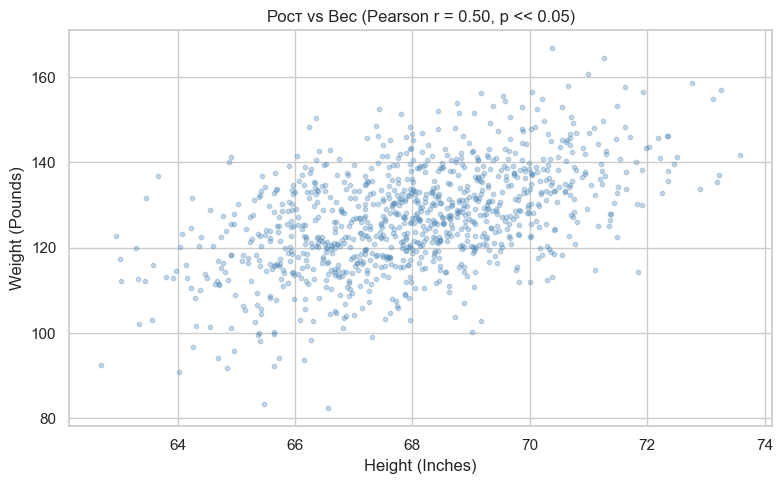

In [ ]:
pearson_r, pearson_p = stats.pearsonr(df_hw['Height(Inches)'], df_hw['Weight(Pounds)'])
spearman_r, spearman_p = stats.spearmanr(df_hw['Height(Inches)'], df_hw['Weight(Pounds)'])

print(f"Pearson r  = {pearson_r:.4f}, p = {pearson_p:.2e}")
print(f"Spearman r = {spearman_r:.4f}, p = {spearman_p:.2e}")
print()
print("Оба значимы - высокая корреляция между ростом и весом")

fig, ax = plt.subplots(figsize=(8, 5))
sample_hw = df_hw.sample(1000, random_state=42)
ax.scatter(sample_hw['Height(Inches)'], sample_hw['Weight(Pounds)'], alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('Height (Inches)')
ax.set_ylabel('Weight (Pounds)')
ax.set_title(f'Рост vs Вес (Pearson r = {pearson_r:.2f}, p << 0.05)')
plt.tight_layout()
plt.show()

---
##  Мини-кейсы

### Кейс 1: Средний рост отличается от нормы 67.0"?

In [ ]:
print("Вопрос: Средний рост статистически отличается от 67.0?")
print()
print("H₀: μ = 67.0")
print("H₁: μ ≠ 67.0")
print()

print("--- Проверка условий ---")
print(f" n = {len(height)} (достаточно большая выборка)")
print(" Нормальность: по ЦПТ при n=25000 среднее нормально")
print(" Независимость: каждый человек - отдельный объект")
print()

t, p = stats.ttest_1samp(height, 67.0)
ci = stats.t.interval(0.95, df=len(height)-1, loc=height.mean(), scale=stats.sem(height))

print(f"Среднее выборки: {height.mean():.4f}")
print(f"t = {t:.4f}, p = {p:.2e}")
print(f"95% CI: [{ci[0]:.4f}, {ci[1]:.4f}]")
print()
print(f"p = {p:.2e} << 0.05 -> Отвергаем H₀")
print(f"Среднее {height.mean():.4f} статистически значимо отличается от 67.0.")
print(f"Значение 67.0 не попадает в 95% CI [{ci[0]:.4f}, {ci[1]:.4f}].")

КЕЙС 1: Одновыборочный t-тест
Вопрос: Средний рост статистически отличается от 67.0?

H₀: μ = 67.0
H₁: μ ≠ 67.0

--- Проверка условий ---
 n = 25000 (достаточно большая выборка)
 Нормальность: по ЦПТ при n=25000 среднее нормально
 Независимость: каждый человек - отдельный объект

--- Результат ---
Среднее выборки: 67.9931
t = 82.5718, p = 0.00e+00
95% CI: [67.9695, 68.0167]

--- Вывод ---
p = 0.00e+00 << 0.05 -> Отвергаем H₀
Среднее 67.9931 статистически значимо отличается от 67.0.
Значение 67.0 не попадает в 95% CI [67.9695, 68.0167].


### Кейс 2: Выживаемость на Титанике зависит от пола?

In [ ]:
print("Вопрос: Зависит ли выживаемость от пола пассажира?")
print()
print("H₀: Пол и выживаемость независимы")
print("H₁: Есть зависимость")
print()

ct2 = pd.crosstab(df_titanic['Sex'], df_titanic['Survived'])
chi2, p, dof, expected = stats.chi2_contingency(ct2)

print(f"Оба признака категориальные")
print(f"Минимальная ожидаемая частота: {expected.min():.1f} (≥ 5)")
print(f"Независимые наблюдения")
print()

print("--- Результат ---")
print(f"χ² = {chi2:.4f}, df = {dof}, p = {p:.2e}")
print()
print("--- Вывод ---")
print(f"p = {p:.2e} << 0.05 -> Отвергаем H₀")
print("Зависимость между полом и выживаемостью статистически значима.")
print(f"Женщины выживали в {df_titanic[df_titanic['Sex']=='female']['Survived'].mean():.1%} случаев,")
print(f"мужчины - в {df_titanic[df_titanic['Sex']=='male']['Survived'].mean():.1%}.")
print("Это не случайность - подтверждено статистически.")

Вопрос: Зависит ли выживаемость от пола пассажира?

H₀: Пол и выживаемость независимы
H₁: Есть зависимость

--- Проверка условий ---
Оба признака категориальные
Минимальная ожидаемая частота: 120.5 (≥ 5)
Независимые наблюдения

--- Результат ---
χ² = 260.7170, df = 1, p = 1.20e-58

--- Вывод ---
p = 1.20e-58 << 0.05 -> Отвергаем H₀
Зависимость между полом и выживаемостью статистически значима.
Женщины выживали в 74.2% случаев,
мужчины - в 18.9%.
Это не случайность - подтверждено статистически.


: 

### Кейс 3: Senior-инженеры зарабатывают значимо больше Mid-level?

In [ ]:
df_salary = pd.read_csv('datasets/salary.csv')
senior = df_salary[df_salary['experience_level'] == 'SE']['salary_in_usd']
mid = df_salary[df_salary['experience_level'] == 'MI']['salary_in_usd']

print("Вопрос: Senior зарабатывают значимо больше Mid-level?")
print()
print("H₀: Зарплаты SE и MI одинаковы")
print("H₁: Зарплаты SE > MI")
print()

print(f"n(SE) = {len(senior)}, n(MI) = {len(mid)} (достаточно данных)")
_, p_se = stats.shapiro(senior.sample(1000, random_state=42))
_, p_mi = stats.shapiro(mid.sample(1000, random_state=42))
print(f"Shapiro-Wilk SE: p = {p_se:.4f} -> {'нормальное' if p_se > 0.05 else ' НЕ нормальное -> Mann-Whitney'}")
print(f"Shapiro-Wilk MI: p = {p_mi:.4f} -> {'нормальное' if p_mi > 0.05 else ' НЕ нормальное -> Mann-Whitney'}")
print()

stat, p_value = stats.mannwhitneyu(senior, mid, alternative='greater')

# CI для медиан (bootstrap)
def bootstrap_median_ci(data, n_boot=2000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    medians = [np.median(rng.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    lower = np.percentile(medians, (1-ci)/2 * 100)
    upper = np.percentile(medians, (1+ci)/2 * 100)
    return lower, upper

ci_se = bootstrap_median_ci(senior.values)
ci_mi = bootstrap_median_ci(mid.values)

print("--- Результат ---")
print(f"Медиана SE: {senior.median():,.0f} USD, 95% CI [{ci_se[0]:,.0f}, {ci_se[1]:,.0f}]")
print(f"Медиана MI: {mid.median():,.0f} USD, 95% CI [{ci_mi[0]:,.0f}, {ci_mi[1]:,.0f}]")
print(f"U = {stat:.0f}, p = {p_value:.2e}")
print()
print("--- Вывод ---")
if p_value < 0.05:
    print(f"p = {p_value:.2e} << 0.05 -> Отвергаем H₀")
    print(f"Senior зарабатывают статистически значимо больше, чем Mid-level.")
    diff_median = senior.median() - mid.median()
    print(f"Разница медиан: {diff_median:,.0f} USD в год.")

КЕЙС 3: Mann-Whitney U тест
Вопрос: Senior зарабатывают значимо больше Mid-level?

H₀: Зарплаты SE и MI одинаковы
H₁: Зарплаты SE > MI

--- Проверка условий ---
n(SE) = 10670, n(MI) = 4038 (достаточно данных)
Shapiro-Wilk SE: p = 0.0000 ->  НЕ нормальное -> Mann-Whitney
Shapiro-Wilk MI: p = 0.0000 ->  НЕ нормальное -> Mann-Whitney

--- Результат ---
Медиана SE: 155,000 USD, 95% CI [153,400, 156,400]
Медиана MI: 115,000 USD, 95% CI [112,000, 117,000]
U = 29798410, p = 6.18e-283

--- Вывод ---
p = 6.18e-283 << 0.05 -> Отвергаем H₀
Senior зарабатывают статистически значимо больше, чем Mid-level.
Разница медиан: 40,000 USD в год.


# Задание. Провести тест на каком-либо своём наборе данных